In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tcs = pd.read_csv("TCS.csv")

In [3]:
tcs

,Price,Close,High,Low,Open,Volume
0,Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,1561.00048828125,1566.9071137839242,1546.3978583679043,1555.421930750953,1094883
3,2019-01-02,1577.818115234375,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463
4,2019-01-03,1558.662353515625,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668
...,...,...,...,...,...,...
1477,2024-12-23,3893.97119140625,3948.940020065292,3853.330069463599,3933.0672895418265,2195338
1478,2024-12-24,3913.824462890625,3949.8771586248727,3893.971886498204,3893.971886498204,1181886
1479,2024-12-26,3904.085693359375,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464
1480,2024-12-27,3900.10546875,3915.1821407656116,3883.624146371002,3898.372975186565,858100


In [4]:
tcs.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [5]:
tcs= tcs.iloc[2:].reset_index(drop=True)

In [6]:
tcs

,Price,Close,High,Low,Open,Volume
0,2019-01-01,1561.00048828125,1566.9071137839242,1546.3978583679043,1555.421930750953,1094883
1,2019-01-02,1577.818115234375,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463
2,2019-01-03,1558.662353515625,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668
3,2019-01-04,1539.7119140625,1559.6879100155566,1510.3016600483052,1558.7035057532753,4280862
4,2019-01-07,1556.9803466796875,1565.9224003035415,1543.1160727281522,1551.9761093751106,1856423
...,...,...,...,...,...,...
1475,2024-12-23,3893.97119140625,3948.940020065292,3853.330069463599,3933.0672895418265,2195338
1476,2024-12-24,3913.824462890625,3949.8771586248727,3893.971886498204,3893.971886498204,1181886
1477,2024-12-26,3904.085693359375,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464
1478,2024-12-27,3900.10546875,3915.1821407656116,3883.624146371002,3898.372975186565,858100


In [7]:
tcs = tcs.rename(columns={"Price" : "Date", "Close": "Close_price","High": "High_price","Low": "Low_price","Open": "Open_price"})

In [8]:
tcs

,Date,Close_price,High_price,Low_price,Open_price,Volume
0,2019-01-01,1561.00048828125,1566.9071137839242,1546.3978583679043,1555.421930750953,1094883
1,2019-01-02,1577.818115234375,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463
2,2019-01-03,1558.662353515625,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668
3,2019-01-04,1539.7119140625,1559.6879100155566,1510.3016600483052,1558.7035057532753,4280862
4,2019-01-07,1556.9803466796875,1565.9224003035415,1543.1160727281522,1551.9761093751106,1856423
...,...,...,...,...,...,...
1475,2024-12-23,3893.97119140625,3948.940020065292,3853.330069463599,3933.0672895418265,2195338
1476,2024-12-24,3913.824462890625,3949.8771586248727,3893.971886498204,3893.971886498204,1181886
1477,2024-12-26,3904.085693359375,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464
1478,2024-12-27,3900.10546875,3915.1821407656116,3883.624146371002,3898.372975186565,858100


In [9]:
tcs_close = tcs["Close_price"]

In [10]:
tcs_close # as the type is object not numeric 

0         1561.00048828125
1        1577.818115234375
2        1558.662353515625
3          1539.7119140625
4       1556.9803466796875
               ...        
1475      3893.97119140625
1476     3913.824462890625
1477     3904.085693359375
1478         3900.10546875
1479      3894.43994140625
Name: Close_price, Length: 1480, dtype: object

In [11]:
tcs_close.isnull().sum()

np.int64(0)

In [12]:
tcs["Close_price"] = pd.to_numeric(
    tcs["Close_price"],
    errors="coerce"
)

In [13]:
tcs["Close_price"]

0       1561.000488
1       1577.818115
2       1558.662354
3       1539.711914
4       1556.980347
           ...     
1475    3893.971191
1476    3913.824463
1477    3904.085693
1478    3900.105469
1479    3894.439941
Name: Close_price, Length: 1480, dtype: float64

In [14]:
tcs["Return"] = tcs["Close_price"].pct_change()  # Rt=( Pt−1 - Pt)/Pt−1

In [15]:
tcs  

,Date,Close_price,High_price,Low_price,Open_price,Volume,Return
0,2019-01-01,1561.000488,1566.9071137839242,1546.3978583679043,1555.421930750953,1094883,NaN
1,2019-01-02,1577.818115,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463,0.010774
2,2019-01-03,1558.662354,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668,-0.012141
3,2019-01-04,1539.711914,1559.6879100155566,1510.3016600483052,1558.7035057532753,4280862,-0.012158
4,2019-01-07,1556.980347,1565.9224003035415,1543.1160727281522,1551.9761093751106,1856423,0.011215
...,...,...,...,...,...,...,...
1475,2024-12-23,3893.971191,3948.940020065292,3853.330069463599,3933.0672895418265,2195338,-0.002878
1476,2024-12-24,3913.824463,3949.8771586248727,3893.971886498204,3893.971886498204,1181886,0.005098
1477,2024-12-26,3904.085693,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464,-0.002488
1478,2024-12-27,3900.105469,3915.1821407656116,3883.624146371002,3898.372975186565,858100,-0.001020


In [16]:
tcs = tcs.dropna().reset_index(drop = True) #  1st row was removed as no previous day to calculate the return 

In [17]:
tcs

,Date,Close_price,High_price,Low_price,Open_price,Volume,Return
0,2019-01-02,1577.818115,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463,0.010774
1,2019-01-03,1558.662354,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668,-0.012141
2,2019-01-04,1539.711914,1559.6879100155566,1510.3016600483052,1558.7035057532753,4280862,-0.012158
3,2019-01-07,1556.980347,1565.9224003035415,1543.1160727281522,1551.9761093751106,1856423,0.011215
4,2019-01-08,1553.411499,1563.9532324461793,1545.0027073599458,1563.13286252779,1691756,-0.002292
...,...,...,...,...,...,...,...
1474,2024-12-23,3893.971191,3948.940020065292,3853.330069463599,3933.0672895418265,2195338,-0.002878
1475,2024-12-24,3913.824463,3949.8771586248727,3893.971886498204,3893.971886498204,1181886,0.005098
1476,2024-12-26,3904.085693,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464,-0.002488
1477,2024-12-27,3900.105469,3915.1821407656116,3883.624146371002,3898.372975186565,858100,-0.001020


In [18]:
tcs["Return_pct"] = tcs["Return"] *100

In [19]:
tcs

,Date,Close_price,High_price,Low_price,Open_price,Volume,Return,Return_pct
0,2019-01-02,1577.818115,1586.9651632531084,1558.7034486750615,1562.8052998557853,2100463,0.010774,1.077362
1,2019-01-03,1558.662354,1595.5790132754998,1553.042837558525,1574.2904462044448,2611668,-0.012141,-1.214067
2,2019-01-04,1539.711914,1559.6879100155566,1510.3016600483052,1558.7035057532753,4280862,-0.012158,-1.215814
3,2019-01-07,1556.980347,1565.9224003035415,1543.1160727281522,1551.9761093751106,1856423,0.011215,1.121537
4,2019-01-08,1553.411499,1563.9532324461793,1545.0027073599458,1563.13286252779,1691756,-0.002292,-0.229216
...,...,...,...,...,...,...,...,...
1474,2024-12-23,3893.971191,3948.940020065292,3853.330069463599,3933.0672895418265,2195338,-0.002878,-0.287752
1475,2024-12-24,3913.824463,3949.8771586248727,3893.971886498204,3893.971886498204,1181886,0.005098,0.509846
1476,2024-12-26,3904.085693,3932.974763441001,3879.7850567984137,3913.8245120496226,1208464,-0.002488,-0.248830
1477,2024-12-27,3900.105469,3915.1821407656116,3883.624146371002,3898.372975186565,858100,-0.001020,-0.101950


In [20]:
mu = tcs["Return"].mean()

* 0.07345% average daily return

In [21]:
tcs["Return"].std()

0.015252087404803048

In [22]:
sigma = tcs["Return_pct"].std()

In [23]:
sigma

1.5252087404803059

* 1.5252% daily volatility

 * These two values are literally the parameters we'll infer later using Bayes.

In [34]:
tcs.to_csv("Data_with_returns/TCS_returns.csv",index = False)

In [25]:
tcs["Date"] = pd.to_datetime(tcs["Date"])

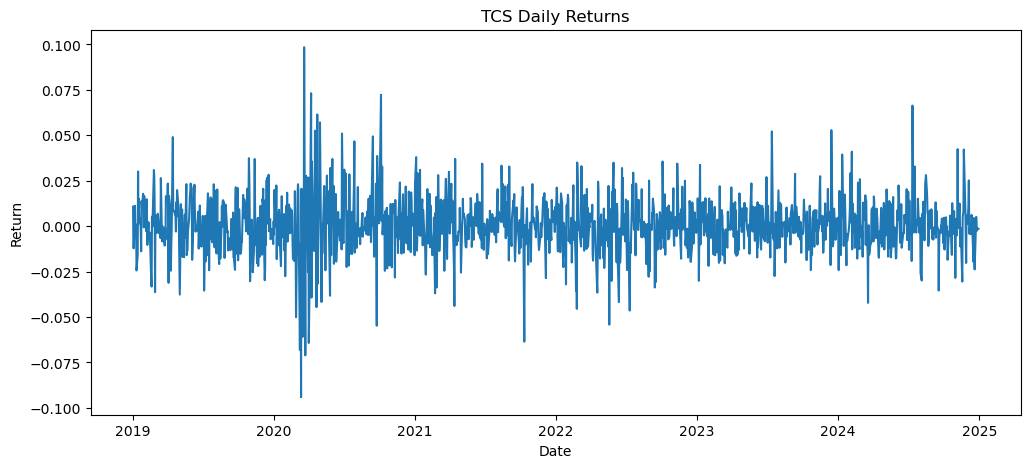

In [26]:
plt.figure(figsize=(12,5))    #it is showing the stability of the returns(it's mostly near zero but some time showing  very high spikes)

plt.plot(
    tcs["Date"],
    tcs["Return"]
)
plt.xlabel("Date")
plt.ylabel("Return")

plt.title("TCS Daily Returns")

plt.savefig("TCS_returns.png", dpi=300, bbox_inches="tight")
plt.show()

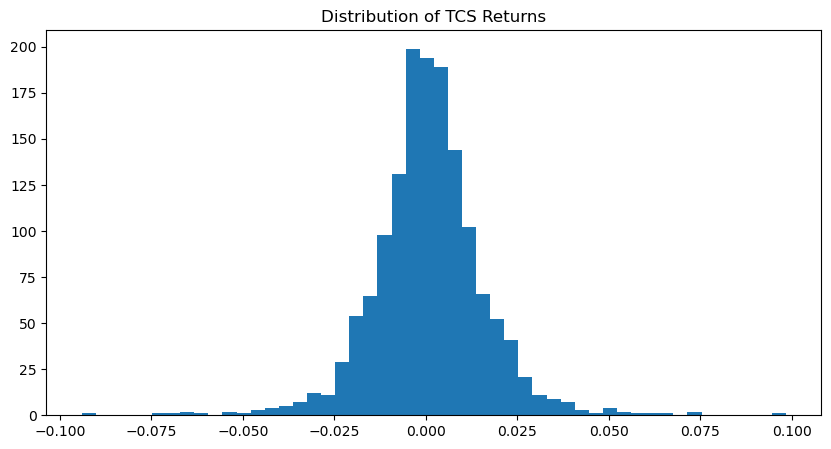

In [27]:
plt.figure(figsize=(10,5))  #(most imp) it is showing what kind of distribution is followed by returns ( Normal, student-t)

plt.hist(
    tcs["Return"],
    bins=50
)

plt.title("Distribution of TCS Returns")

plt.savefig("TCS_returns_Hist.png", dpi=300, bbox_inches="tight")
plt.show()

# Now looping for all other companies stocks 

In [28]:
def compute_returns(df):

    df["Return"] = df["Close_price"].pct_change()

    df["Return_pct"] = df["Return"] *100

    df = df.dropna().reset_index(drop = True)

    return df

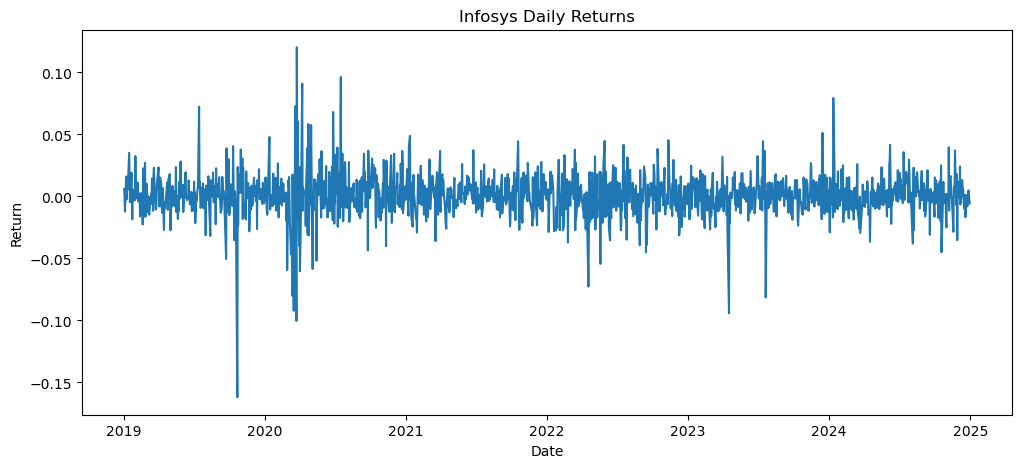

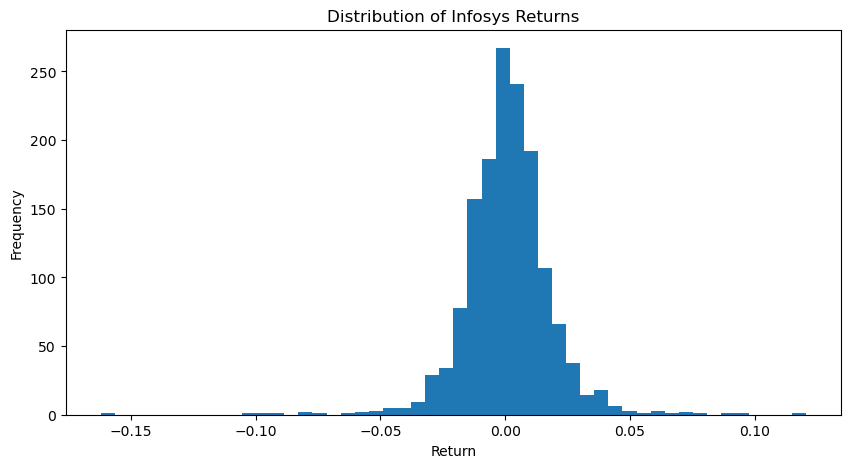

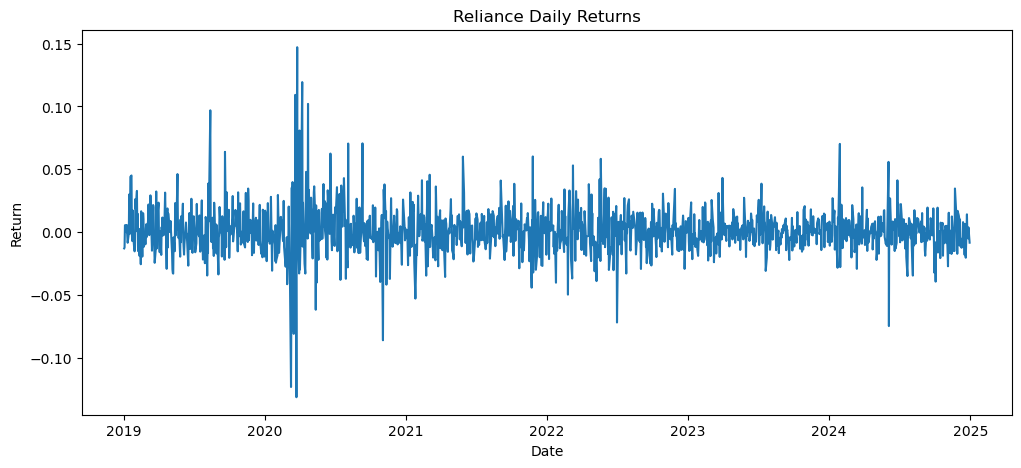

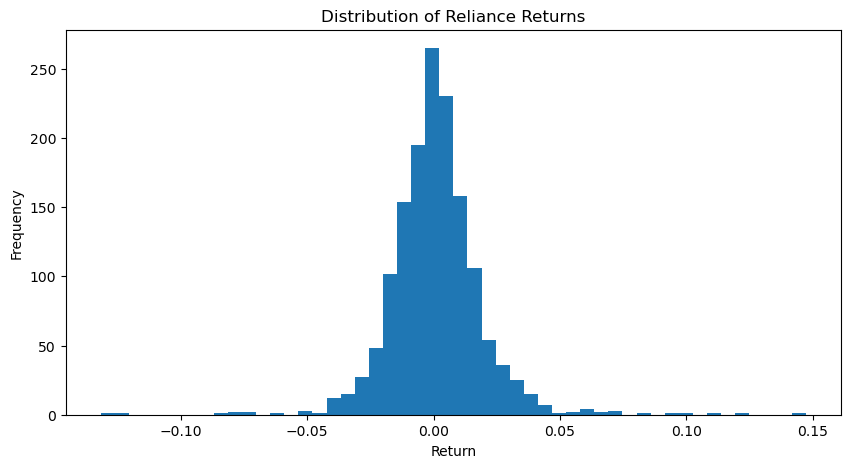

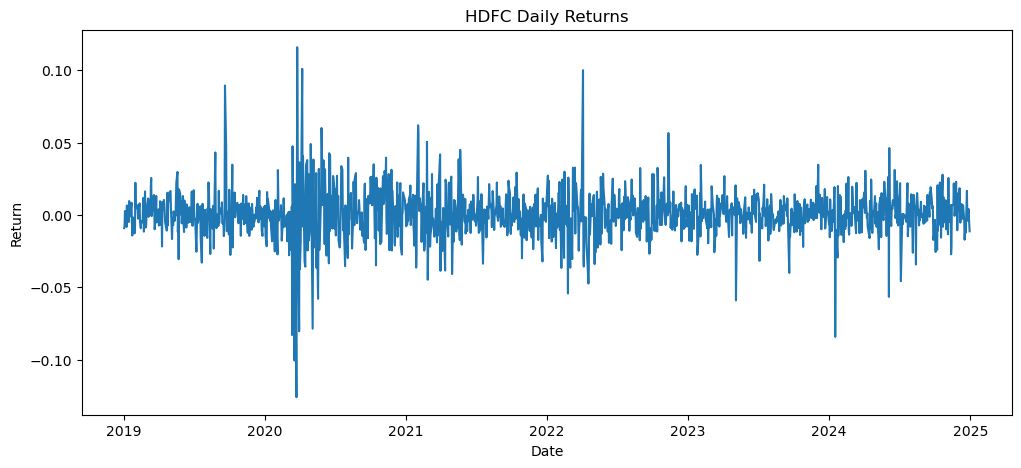

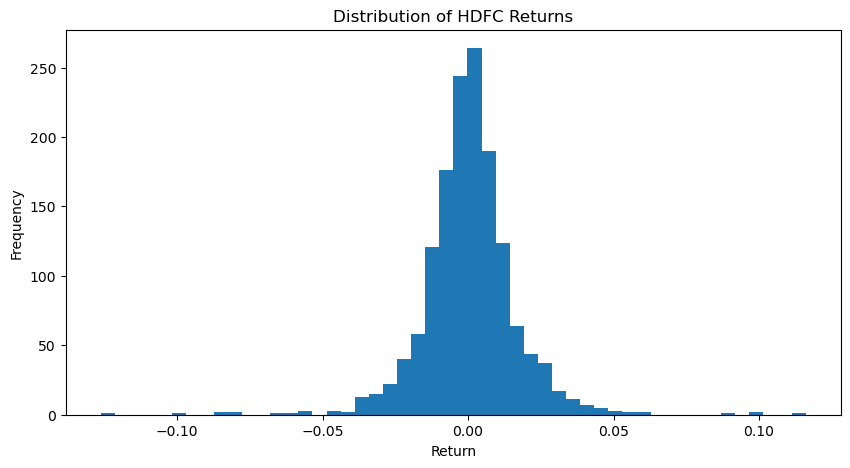

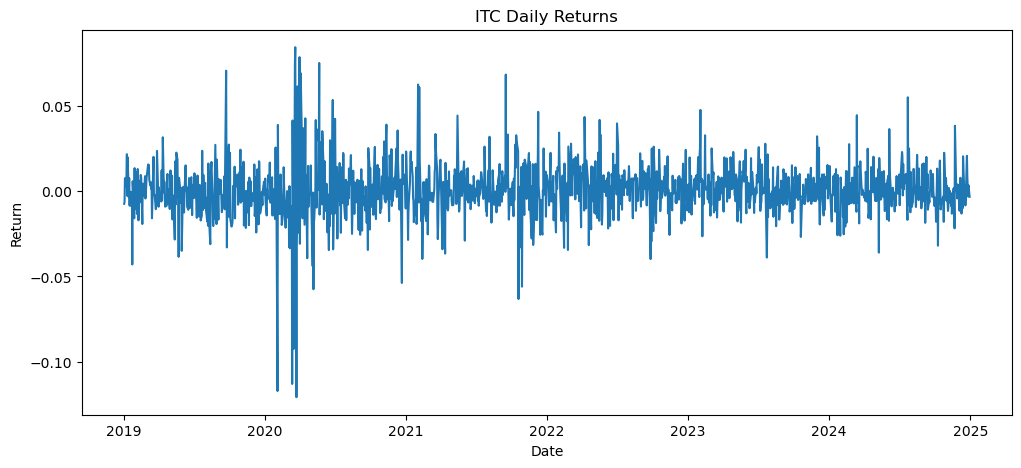

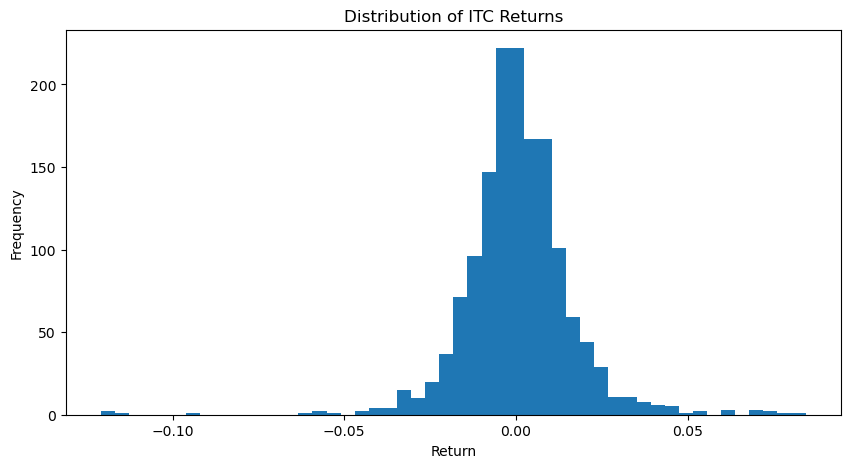

In [29]:
stocks = [ "Infosys", "Reliance", "HDFC", "ITC" ]

for stock in stocks:

    df = pd.read_csv(f"{stock}.csv")

    df = df.iloc[2:].reset_index(drop=True)

    df = df.rename(columns={
        "Price": "Date",
        "Close": "Close_price",
        "High": "High_price",
        "Low": "Low_price",
        "Open": "Open_price"
    })

    df["Date"] = pd.to_datetime(df["Date"])

    df["Close_price"] = pd.to_numeric(
        df["Close_price"],
        errors="coerce"
    )

    df = compute_returns(df)


    # Return Plot
    plt.figure(figsize=(12,5))
    plt.plot(df["Date"], df["Return"])

    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.title(f"{stock} Daily Returns")

    plt.savefig(
        f"{stock}_returns.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Histogram
    plt.figure(figsize=(10,5))

    plt.hist(
        df["Return"].dropna(),
        bins=50
    )

    plt.title(
        f"Distribution of {stock} Returns"
    )

    plt.xlabel("Return")
    plt.ylabel("Frequency")

    plt.savefig(
        f"{stock}_returns_hist.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    df.to_csv(
        f"{stock}_returns.csv",
        index=False
    )

In [40]:
Tcs = pd.read_csv("Data_with_returns/TCS_returns.csv")# Load stock-specific file
Tcs.head()

,Date,Close_price,High_price,Low_price,Open_price,Volume,Return,Return_pct
0,2019-01-02,1577.818115,1586.965163,1558.703449,1562.805300,2100463,0.010774,1.077362
1,2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668,-0.012141,-1.214067
2,2019-01-04,1539.711914,1559.687910,1510.301660,1558.703506,4280862,-0.012158,-1.215814
3,2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423,0.011215,1.121537
4,2019-01-08,1553.411499,1563.953232,1545.002707,1563.132863,1691756,-0.002292,-0.229216


In [43]:
stocks = ["TCS", "Infosys", "Reliance", "HDFC", "ITC" ]
summary_Data = []

for stock in stocks:
        
    df = pd.read_csv(f"Data_with_returns/{stock}_returns.csv")# Load stock-specific file
    df.head()
    mean_return = df["Return"].mean()
    volatility = df["Return"].std()

    print(f"\n{stock}")
    print(f"Mean Return: {mean_return:.6f}")
    print(f"Volatility : {volatility:.6f}")


    summary_Data.append({
        "Stock": stock,
        "Mean Return": mean_return,
        "Volatility": volatility
    })

summary_df = pd.DataFrame(summary_Data)

summary_df.to_csv(
    "return_summary.csv",
    index=False
)


TCS
Mean Return: 0.000735
Volatility : 0.015252

Infosys
Mean Return: 0.000972
Volatility : 0.017546

Reliance
Mean Return: 0.000767
Volatility : 0.018463

HDFC
Mean Return: 0.000510
Volatility : 0.016488

ITC
Mean Return: 0.000645
Volatility : 0.015808
